# PCA Relative Value Butterfly Backtest

**Methodology:** Standard Chartered two-stage PCA (Lee, Davies, Fernandez 2013)
- **Stage 1:** Full-curve PCA scan across the forward surface → Z-score rich/cheap map
- **Stage 2:** Trade-specific PCA on 3 selected tenors → level+slope-neutral weights
- **Stage 3:** Ornstein-Uhlenbeck mean-reversion analytics → entry/exit/horizon
- **Stage 4:** Carry/roll-down integration + profitability filter

**Curve:** USD SOFR (ERIS EOD LIVE)  
**Structures:** Butterfly trades only

## 1. Config & Data Loading

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import sys
sys.path.append("../../")

In [2]:
import datetime
import warnings
warnings.filterwarnings("ignore")

import pytz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from BT.signals.pca_rv_scanner import (
    PCARVScannerConfig, scan_forward_surface, zscore_snapshot,
    identify_candidates, analyze_candidates, build_signal_table,
    build_rate_queries, build_carry_roll_queries, reshape_rates_panel,
)
from BT.signals.pca_rv_triggers import PCARVEntryTrigger, PCARVExitTrigger

tz = pytz.timezone("America/New_York")
config = PCARVScannerConfig()

# Date range
data_start = datetime.datetime(2022, 1, 1, 17, tzinfo=tz)
data_end = datetime.datetime(2026, 3, 20, 17, tzinfo=tz)

print(f"Config: {config.curve} / {config.source}")
print(f"Tenors: {config.tenors}")
print(f"Forward starts: {config.forward_starts}")
print(f"PCA window: {config.pca_window_days}d, Z-score window: {config.zscore_lookback_days}d")
print(f"Min Z-score entry: {config.min_zscore_entry}, Max ADF p-value: {config.max_adf_pvalue}")
print(f"Fly categories: {list(config.fly_tenor_categories.keys())}")

Config: USD-SOFR-1D / ERIS_EOD_LIVE-RL_BASIC
Tenors: ['1Y', '2Y', '3Y', '4Y', '5Y', '7Y', '8Y', '9Y', '10Y', '15Y', '20Y', '25Y', '30Y']
Forward starts: [None, '1M', '3M', '6M', '1Y', '2Y', '5Y', '7Y', '10Y']
PCA window: 520d, Z-score window: 520d
Min Z-score entry: 1.5, Max ADF p-value: 0.05
Fly categories: ['front_end', 'belly', 'long_end']


In [3]:
# Load rates via TimeseriesBuilder
from TB.TimeseriesBuilder import TimeseriesBuilder
from TB.IRSwapsTB import IRSwapsTB
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

curve_mdp = IRSwapsMDP(source=config.source)
ts_builder = TimeseriesBuilder()
queries = build_rate_queries(config)
router = {"IRS": IRSwapsTB(curve_mdp, show_tqdm=True)}

print(f"Fetching {len(queries)} rate queries...")
rates_df = ts_builder.get_timeseries(
    start=data_start, end=data_end, queries=queries, n_jobs=12, routers=router,
)
panels = reshape_rates_panel(rates_df, config)
print(f"Loaded panels for {len(panels)} forward starts")
print(f"Date range: {rates_df.index[0]} to {rates_df.index[-1]}")
print(f"Spot panel shape: {panels.get(None, pd.DataFrame()).shape}")

DuckDB unavailable (file locked), falling back to parquet-only: C:\Users\chris\clee\ARBS\data\ts\computed_ts.duckdb


Fetching 117 rate queries...


Loaded panels for 9 forward starts
Date range: 2022-01-03 to 2026-03-20
Spot panel shape: (1052, 13)


## 2. Stage 1: Surface Scan

In [9]:
# Run full-surface PCA scan
print("Running Stage 1: Full-curve PCA surface scan...")
result = scan_forward_surface(panels, config)

# Z-score snapshot (SC Figure 12)
snap = zscore_snapshot(result)
print("\nZ-Score Snapshot (last date) — rows=tenors, cols=forward starts:")
print("Green = cheap (positive Z, rates above fair value)")
print("Blue = rich (negative Z, rates below fair value)\n")

def _color_zscore(val):
    if pd.isna(val):
        return ""
    if val > 1.5:
        return "color: green; font-weight: bold"
    if val > 0:
        return "color: green"
    if val < -1.5:
        return "color: white; font-weight: bold"
    if val < 0:
        return "color: white"
    return ""

snap.style.map(_color_zscore).format("{:.2f}")

Running Stage 1: Full-curve PCA surface scan...

Z-Score Snapshot (last date) — rows=tenors, cols=forward starts:
Green = cheap (positive Z, rates above fair value)
Blue = rich (negative Z, rates below fair value)



,Spot,1M,3M,6M,1Y,2Y,5Y,7Y,10Y
1Y,-0.52,-1.85,-1.04,0.25,2.08,0.79,1.11,0.94,-1.41
2Y,0.00,2.02,1.18,-0.23,-1.96,-2.16,-0.72,-1.04,-0.10
3Y,0.69,0.62,0.01,-0.86,-2.50,-0.00,-1.45,-1.23,0.57
4Y,0.50,-0.95,-0.95,-0.57,0.15,0.81,-1.23,-0.87,0.73
5Y,-0.59,-0.47,0.64,1.73,2.23,0.39,-0.91,-0.33,0.80
7Y,0.50,-0.51,0.07,0.84,1.78,-0.71,0.54,1.41,2.11
8Y,0.56,-0.67,-0.18,0.47,1.38,-0.53,1.81,1.35,2.03
9Y,0.58,-0.76,-0.35,0.22,1.20,-0.24,1.59,1.32,0.74
10Y,-0.59,-0.79,-0.40,0.12,1.10,0.17,1.28,1.37,0.11
15Y,-0.59,0.08,0.18,0.31,0.87,0.75,1.15,-0.11,-1.17


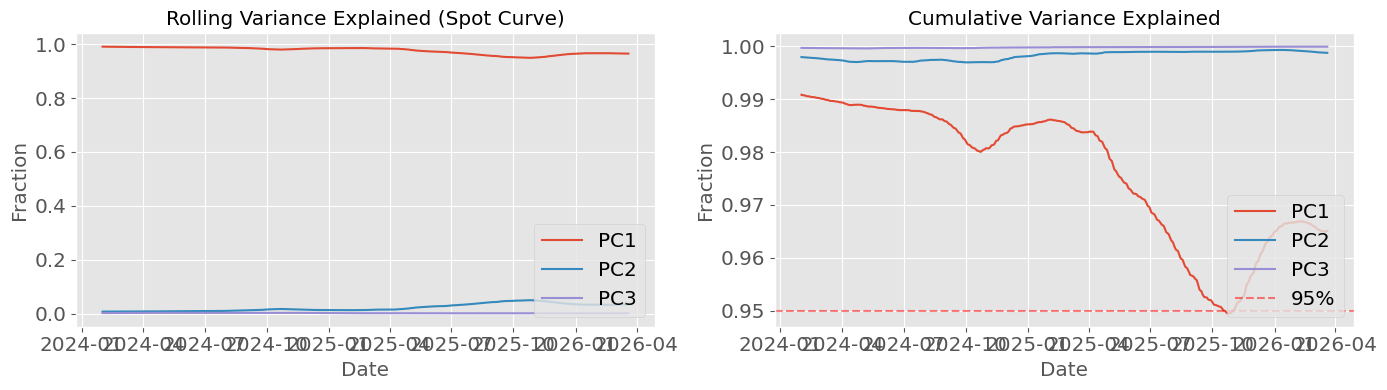

Average total variance explained: 100.0%


In [10]:
# Variance explained by first 3 PCs (spot curve)
if None in result.variance_explained:
    ve = result.variance_explained[None].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Left: rolling variance explained
    ve.plot(ax=axes[0], title="Rolling Variance Explained (Spot Curve)")
    axes[0].set_ylabel("Fraction")
    axes[0].legend(loc="lower right")
    
    # Right: cumulative
    ve_cum = ve.cumsum(axis=1)
    ve_cum.plot(ax=axes[1], title="Cumulative Variance Explained")
    axes[1].set_ylabel("Fraction")
    axes[1].axhline(0.95, color="red", linestyle="--", alpha=0.5, label="95%")
    axes[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()
    print(f"Average total variance explained: {ve.sum(axis=1).mean():.1%}")

## 3. Stage 2: Candidates

In [11]:
# Identify candidates at the latest date
candidates = identify_candidates(result, panels, config)
print(f"Found {len(candidates)} candidates at latest date\n")

if candidates:
    cand_df = pd.DataFrame([{
        "Forward": c.forward_start or "Spot",
        "Fly": f"{c.tenors[0]}/{c.tenors[1]}/{c.tenors[2]}",
        "Weights": f"{c.weights[0]:.2f} / 1.00 / {c.weights[2]:.2f}",
        "Direction": c.direction,
        "Z(belly)": f"{c.zscore_belly:.2f}",
        "Z(left)": f"{c.zscore_left:.2f}",
        "Z(right)": f"{c.zscore_right:.2f}",
        "PC1 neut": f"{c.neutrality_check[0]:.2e}",
        "PC2 neut": f"{c.neutrality_check[1]:.2e}",
    } for c in candidates])
    display(cand_df)
else:
    print("No candidates found at the latest date (may appear during rolling backtest)")

Found 2 candidates at latest date



,Forward,Fly,Weights,Direction,Z(belly),Z(left),Z(right),PC1 neut,PC2 neut
0,7Y,10Y/20Y/30Y,-0.34 / 1.00 / -0.66,pay_belly,-1.53,1.37,1.26,-2.22e-16,5.55e-17
1,10Y,10Y/20Y/30Y,-0.36 / 1.00 / -0.64,pay_belly,-2.70,0.11,1.97,2.78e-16,0.00e+00


## 4. Stage 3: OU Analytics

In [12]:
# Analyze candidates with OU model
if candidates:
    trades = analyze_candidates(candidates, panels, config)
    print(f"Analyzed {len(trades)} trades\n")
    
    if trades:
        trade_df = pd.DataFrame([{
            "Fly": f"{t.candidate.tenors[0]}/{t.candidate.tenors[1]}/{t.candidate.tenors[2]}",
            "Fwd": t.candidate.forward_start or "Spot",
            "Direction": t.candidate.direction,
            "Lifetime Z": f"{t.lifetime_zscore:.2f}",
            "Entry": f"{t.current_level*100:.1f}bps",
            "Target": f"{t.target_level*100:.1f}bps",
            "Stop": f"{t.stop_loss_level*100:.1f}bps",
            "Half-life": f"{t.half_life_days:.0f}d",
            "Horizon": f"{t.investment_horizon_days:.0f}d",
            "ADF p": f"{t.adf_pvalue:.3f}",
            "P/C ratio": f"{t.profit_cost_ratio:.1f}",
            "Pass": t.passes_filter,
        } for t in trades])
        display(trade_df)
else:
    print("No candidates to analyze at latest date")

arbitragelab OU fit failed, falling back: OrnsteinUhlenbeck.fit() missing 2 required positional arguments: 'discount_rate' and 'transaction_cost'
arbitragelab OU fit failed, falling back: OrnsteinUhlenbeck.fit() missing 2 required positional arguments: 'discount_rate' and 'transaction_cost'


Analyzed 2 trades



,Fly,Fwd,Direction,Lifetime Z,Entry,Target,Stop,Half-life,Horizon,ADF p,P/C ratio,Pass
0,10Y/20Y/30Y,7Y,pay_belly,-3.84,7.1bps,8.0bps,6.7bps,5d,14d,0.000,56.0,True
1,10Y/20Y/30Y,10Y,pay_belly,-3.72,6.3bps,7.7bps,5.5bps,2d,6d,0.000,99.0,True


## 5. Backtest

In [13]:
# Build signal table over the backtest period
bt_start = datetime.datetime(2024, 1, 1, 17, tzinfo=tz)
bt_end = data_end

print("Building rolling signal table...")
signal_table = build_signal_table(
    panels, config,
    start_date=pd.Timestamp(bt_start),
    end_date=pd.Timestamp(bt_end),
)
print(f"Signal table: {len(signal_table)} dates with signals")
total_signals = sum(len(v) for v in signal_table.values())
passing_signals = sum(sum(1 for t in v if t.passes_filter) for v in signal_table.values())
print(f"Total signals: {total_signals}, passing filters: {passing_signals}")

Building rolling signal table...


arbitragelab OU fit failed, falling back: OrnsteinUhlenbeck.fit() missing 2 required positional arguments: 'discount_rate' and 'transaction_cost'
arbitragelab OU fit failed, falling back: OrnsteinUhlenbeck.fit() missing 2 required positional arguments: 'discount_rate' and 'transaction_cost'
arbitragelab OU fit failed, falling back: OrnsteinUhlenbeck.fit() missing 2 required positional arguments: 'discount_rate' and 'transaction_cost'
arbitragelab OU fit failed, falling back: OrnsteinUhlenbeck.fit() missing 2 required positional arguments: 'discount_rate' and 'transaction_cost'
arbitragelab OU fit failed, falling back: OrnsteinUhlenbeck.fit() missing 2 required positional arguments: 'discount_rate' and 'transaction_cost'
arbitragelab OU fit failed, falling back: OrnsteinUhlenbeck.fit() missing 2 required positional arguments: 'discount_rate' and 'transaction_cost'
arbitragelab OU fit failed, falling back: OrnsteinUhlenbeck.fit() missing 2 required positional arguments: 'discount_rate' a

Signal table: 10 dates with signals
Total signals: 16, passing filters: 6


In [14]:
# Run event-driven backtest
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.data_handler import TimeGrid

# Wire triggers
entry = PCARVEntryTrigger(signal_table, config, bpv=100_000)
exit_ = PCARVExitTrigger(signal_table, config)
strategy = QueryStrategy("pca_rv_fly", triggers=[entry, exit_], default_mdp=curve_mdp)

# Time grid — use business days from signal table range
bt_dates = pd.bdate_range(bt_start, bt_end, tz=tz)
bt_datetimes = [d.to_pydatetime() for d in bt_dates]

bt = QueryDrivenBacktest(
    time_grid=TimeGrid(bt_datetimes),
    strategy=strategy,
    mdp=curve_mdp,
)

print(f"Running backtest: {bt_start.date()} to {bt_end.date()} ({len(bt_datetimes)} steps)")
bt.run()

Running backtest: 2024-01-01 to 2026-03-20 (580 steps)


BACKTESTING...: 100%|██████████| 580/580 [00:01<00:00, 521.41step/s] 


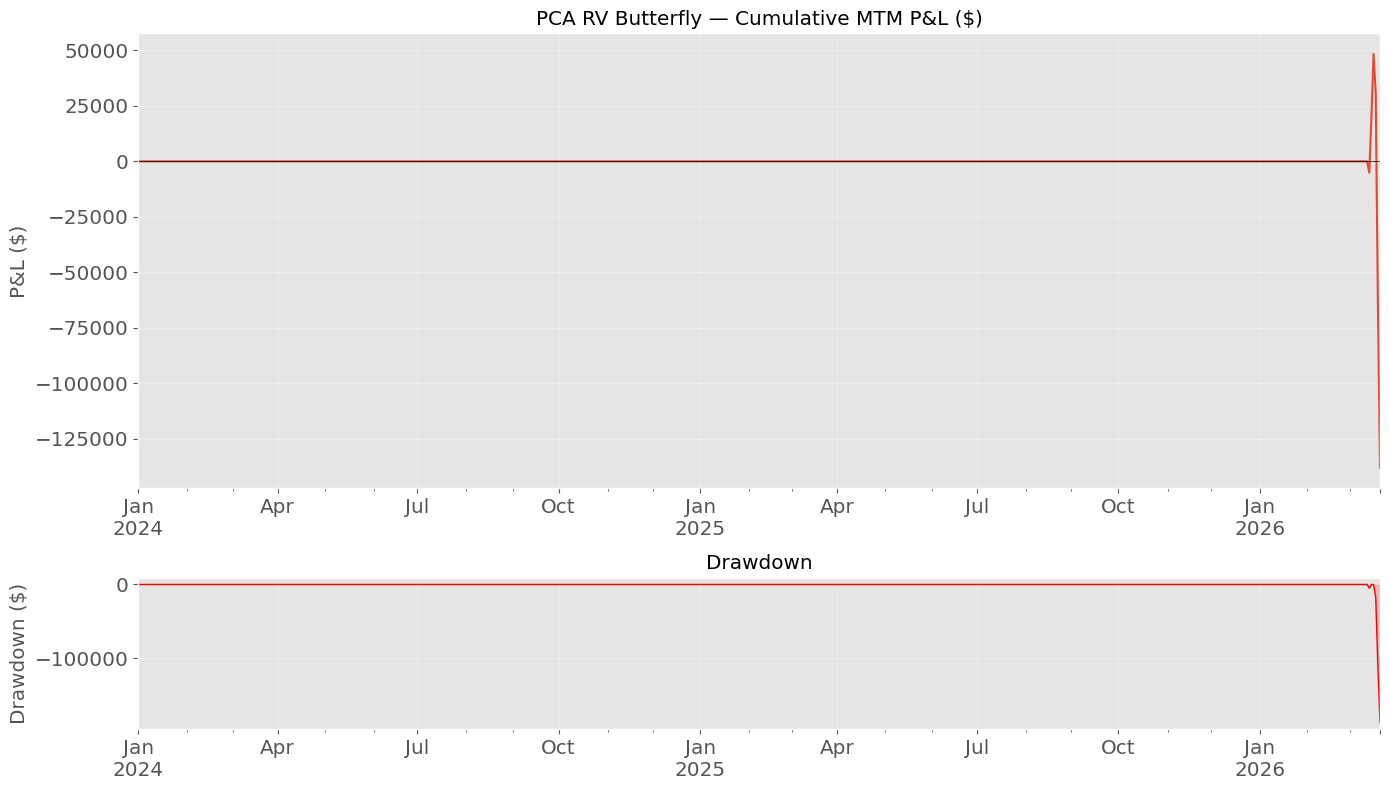


BACKTEST RESULTS
Period:            2024-01-01 to 2026-03-20
Total trades:      2
Final MTM P&L:     $-138,194
Realized P&L:      $0
Sharpe ratio:      -0.72
Max drawdown:      $-186,595
Daily hit rate:    0.3%
Open positions:    2


In [15]:
# Results
mtm = pd.Series(bt.mtm_history).sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [3, 1]})

# Cumulative MTM P&L
mtm.plot(ax=axes[0], title="PCA RV Butterfly — Cumulative MTM P&L ($)", linewidth=1.5)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("P&L ($)")
axes[0].grid(True, alpha=0.3)

# Drawdown
peak = mtm.cummax()
dd = mtm - peak
dd.plot(ax=axes[1], title="Drawdown", color="red", linewidth=1)
axes[1].fill_between(dd.index, dd.values, 0, color="red", alpha=0.2)
axes[1].set_ylabel("Drawdown ($)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats
n_trades = len(bt.portfolio.trades_log)
realized = bt.realized_pnl
final_mtm = mtm.iloc[-1] if len(mtm) > 0 else 0

# Daily returns for Sharpe
daily_pnl = mtm.diff().dropna()
sharpe = (daily_pnl.mean() / daily_pnl.std() * np.sqrt(252)) if daily_pnl.std() > 0 else 0
max_dd = dd.min()
hit_rate = (daily_pnl > 0).mean()

print(f"\n{'='*50}")
print(f"BACKTEST RESULTS")
print(f"{'='*50}")
print(f"Period:            {bt_start.date()} to {bt_end.date()}")
print(f"Total trades:      {n_trades}")
print(f"Final MTM P&L:     ${final_mtm:,.0f}")
print(f"Realized P&L:      ${realized:,.0f}")
print(f"Sharpe ratio:      {sharpe:.2f}")
print(f"Max drawdown:      ${max_dd:,.0f}")
print(f"Daily hit rate:    {hit_rate:.1%}")
print(f"Open positions:    {len(bt.portfolio.positions)}")
print(f"{'='*50}")

In [16]:
# Trade log
if bt.portfolio.trades_log:
    log_df = pd.DataFrame([{
        "Date": str(getattr(o, "timestamp", ""))[:10],
        "Query": str(getattr(o, "query", "")),
        "Meta": str(getattr(o, "meta", {})),
    } for o in bt.portfolio.trades_log])
    print(f"Trade log ({len(log_df)} entries):")
    display(log_df.head(20))
else:
    print("No trades executed during backtest period")

Trade log (2 entries):


,Date,Query,Meta
0,2026-03-12,"IRSwapQuery(product='IRS', structure_id=<IRSwa...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_7Y..."
1,2026-03-19,"IRSwapQuery(product='IRS', structure_id=<IRSwa...","{'action': 'pca_rv_entry', 'tags': ['pca_rv_10..."


## 6. Sensitivity (Placeholder)

Vary `pca_window`, `zscore_entry`, OU horizon to assess impact on Sharpe/hit rate.

In [17]:
# TODO: Sensitivity analysis
# Example: vary min_zscore_entry in [1.0, 1.5, 2.0, 2.5]
# and pca_window_days in [260, 390, 520]
# Re-run build_signal_table + backtest for each combo
# Collect Sharpe, hit rate, max drawdown
print("Sensitivity analysis placeholder — implement per research needs")

Sensitivity analysis placeholder — implement per research needs
